<a href="https://colab.research.google.com/github/AleixoCodes/Machine-Learning-com-dados-do-Spotify/blob/main/Analise_dos_dados_com_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisando dados do Spotify e prevendo músicas populares com Machine Learning**

## **Importando Dados**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [3]:
dadosMusicais = pd.read_csv("/kaggle/input/-spotify-tracks-dataset/dataset.csv")
dadosMusicais

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


### Traduzindo dataframe

In [4]:
dadosMusicais.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

listaEN = ['track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre']

listaPT = ['track_id', 'artistas', 'nome_do_album', 'nome_da_musica',
       'popularidade', 'duracao_ms', 'explicito', 'dancabilidade', 'energia',
       'chave', 'volume', 'modo', 'falada', 'acustica',
       'instrumental', 'ao_vivo', 'positividade', 'tempo', 'tempo_de_assinatura',
       'genero_musical']

dadosMusicais.columns = listaPT
dadosMusicais.head()

,track_id,artistas,nome_do_album,nome_da_musica,popularidade,duracao_ms,explicito,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,genero_musical
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## **Analisando estatísticas dos dados**

In [5]:
dadosMusicais.shape

(114000, 20)

In [6]:
dadosMusicais.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   track_id             114000 non-null  object 
 1   artistas             113999 non-null  object 
 2   nome_do_album        113999 non-null  object 
 3   nome_da_musica       113999 non-null  object 
 4   popularidade         114000 non-null  int64  
 5   duracao_ms           114000 non-null  int64  
 6   explicito            114000 non-null  bool   
 7   dancabilidade        114000 non-null  float64
 8   energia              114000 non-null  float64
 9   chave                114000 non-null  int64  
 10  volume               114000 non-null  float64
 11  modo                 114000 non-null  int64  
 12  falada               114000 non-null  float64
 13  acustica             114000 non-null  float64
 14  instrumental         114000 non-null  float64
 15  ao_vivo          

In [7]:
dadosMusicais.describe()

,popularidade,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
# Analisando valores nulos
dadosMusicais.isnull().sum()

,0
track_id,0
artistas,1
nome_do_album,1
nome_da_musica,1
popularidade,0
duracao_ms,0
explicito,0
dancabilidade,0
energia,0
chave,0


Ranking artistas populares

In [9]:
ranking_popularidade = dadosMusicais[['artistas','popularidade']]
ranking_popularidade = ranking_popularidade.groupby('artistas').mean().sort_values(by='popularidade', ascending=False).reset_index()
ranking_popularidade

,artistas,popularidade
0,Sam Smith;Kim Petras,100.0
1,Bizarrap;Quevedo,99.0
2,Manuel Turizo,98.0
3,Bad Bunny;Chencho Corleone,97.0
4,Bad Bunny;Bomba Estéreo,94.5
...,...,...
31432,Niccolò Paganini;Salvatore Accardo;London Phil...,0.0
31433,Niccolò Paganini;Kanako Yanagida;Kentaro Ifuku,0.0
31434,Whethan;Oliver Tree,0.0
31435,BANKS,0.0


Ranking músicas mais duradouras

In [10]:
long_music = dadosMusicais[['nome_da_musica','duracao_ms']]
long_music = long_music.groupby('nome_da_musica').mean().sort_values(by='duracao_ms', ascending=False).reset_index()
long_music

,nome_da_musica,duracao_ms
0,Unity (Voyage Mix) Pt. 1,5237295.0
1,Crossing Wires 002 - Continuous DJ Mix,4789026.0
2,The Lab 03 - Continuous DJ Mix Part 1,4730302.0
3,Amnesia Ibiza Underground 10 DJ Mix,4563897.0
4,House of Om - Mark Farina - Continuous Mix,4447520.0
...,...,...
73603,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",17826.0
73604,"Andante in C Major, K. 1a",17453.0
73605,Screams for a Finale! (feat. Leila's Opera Class),15800.0
73606,V-4,13386.0


Ranking músicas mais "dançáveis"

In [11]:
danceability_music = dadosMusicais[['nome_da_musica','dancabilidade']]
danceability_music = danceability_music.groupby('nome_da_musica').mean().sort_values(by='dancabilidade', ascending=False).reset_index()
danceability_music

,nome_da_musica,dancabilidade
0,Sol Clap,0.985
1,Medicaid Baby,0.984
2,Daily Routines,0.982
3,"Featuring Mixx Master Lee, Red Rum & J. Smoov ...",0.981
4,Dancing in My Room,0.980
...,...,...
73603,Spray Paint,0.000
73604,Ferme Les Yeux,0.000
73605,Vacum Cleaner,0.000
73606,Ionian,0.000


## **Adaptando os dados para algoritmo**

In [12]:
dadosMusicais.drop_duplicates(inplace=True)
dadosMusicais.dropna(inplace=True)
dadosMusicais['popular_binario'] = dadosMusicais['popularidade'].apply(lambda x: 1 if x >= 60 else 0)
dadosMusicais

,track_id,artistas,nome_do_album,nome_da_musica,popularidade,duracao_ms,explicito,dancabilidade,energia,chave,...,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,genero_musical,popular_binario
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,0
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,0
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,0
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,0


Filtrando DF para dados quantitativos

In [13]:
dados_quantitativos = dadosMusicais
drop_qualitativos = []
for col in dados_quantitativos.columns:
  if dados_quantitativos[col].dtype == 'object':
    drop_qualitativos.append(col)
dados_quantitativos = dados_quantitativos.drop(columns=drop_qualitativos, errors='ignore')

dados_quantitativos = dados_quantitativos.drop(columns=['explicito', 'popularidade'])
dados_quantitativos

,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,popular_binario
0,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,1
1,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,0
2,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,0
3,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,1
4,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,0
113996,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,0
113997,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,0
113998,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,0


Normalizando dados

In [14]:
dadosNormalizados = dados_quantitativos.copy()
dadosNormalizados = (dadosNormalizados - dadosNormalizados.min()) / (dadosNormalizados.max() - dadosNormalizados.min())
dadosNormalizados

,duracao_ms,dancabilidade,energia,chave,volume,modo,falada,acustica,instrumental,ao_vivo,positividade,tempo,tempo_de_assinatura,popular_binario
0,0.042473,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8,1.0
1,0.026971,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8,0.0
2,0.038679,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8,0.0
3,0.036978,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6,1.0
4,0.036389,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.071990,0.174619,0.2350,0.454545,0.612952,1.0,0.043731,0.642570,0.928000,0.0863,0.034070,0.517705,1.0,0.0
113996,0.071990,0.176650,0.1170,0.000000,0.577345,0.0,0.041554,0.997992,0.976000,0.1050,0.035176,0.350242,0.8,0.0
113997,0.050276,0.638579,0.3290,0.000000,0.714648,0.0,0.043523,0.870482,0.000000,0.0839,0.746734,0.543933,0.8,0.0
113998,0.052653,0.595939,0.5060,0.636364,0.714759,1.0,0.030777,0.382530,0.000000,0.2700,0.415075,0.558651,0.8,0.0


### **Divisão do data frame**

Para divisão do dataset, separou-se em treino e teste, sendo que o teste será dividido com 20% de todo o conjunto e será usado somente após o modelo ser escolhido e ajustado.

Já os dados de treino, serão separados em treino e validação. Sendo os dados de validação usados para comparação de diferentes modelos e hiperparâmetros.

- Dados de treinamento: usado para treinar o modelo.

- Dados de validação: usado para comparação de diferentes modelos e hiperparâmetros.

- Dados de teste: usado para comprovar que aquele modelo realmente funciona. São dados ignorados no treinamento e no processo de escolha de hiperparâmetros.

In [15]:
from sklearn.model_selection import train_test_split

# Dividindo dataframe
dadosTreino, dadosTeste = train_test_split(dadosNormalizados, test_size=0.2, random_state=42, shuffle=True)

pop_norm_train = dadosTreino.popular_binario.value_counts(normalize=True)
pop_norm_test = dadosTeste.popular_binario.value_counts(normalize=True)

print(f'População de treino: {pop_norm_train}\n')
print(f'População de teste: {pop_norm_test}')

População de treino: popular_binario
0.0    0.869538
1.0    0.130462
Name: proportion, dtype: float64

População de teste: popular_binario
0.0    0.869617
1.0    0.130383
Name: proportion, dtype: float64


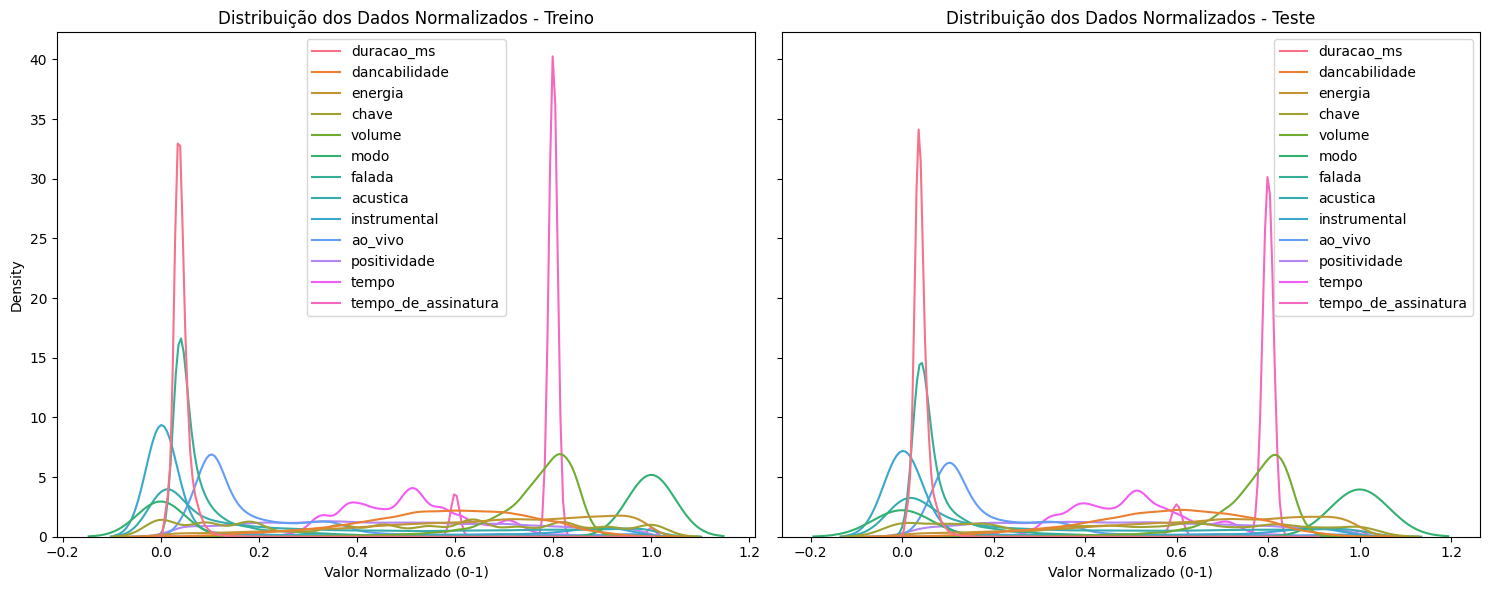

In [16]:
# Configurando a figura para dois subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot para os dados de treino
sns.kdeplot(data=dadosTreino.drop(columns=['popular_binario']), ax=axes[0], common_norm=False)
axes[0].set_title('Distribuição dos Dados Normalizados - Treino')
axes[0].set_xlabel('Valor Normalizado (0-1)')

# Plot para os dados de teste
sns.kdeplot(data=dadosTeste.drop(columns=['popular_binario']), ax=axes[1], common_norm=False)
axes[1].set_title('Distribuição dos Dados Normalizados - Teste')
axes[1].set_xlabel('Valor Normalizado (0-1)')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import StratifiedKFold

# Dividindo em X (características) e y (alvo)
X = dadosTreino.drop(columns=['popular_binario'], axis=1)
y = dadosTreino.popular_binario

# Inicializando o StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Looping para separar dados de treino e validação
# Nota: O loop percorre os folds, mas as variáveis finais conterão apenas o último fold executado
for train_index, val_index in skf.split(X, y):
    X_treino, X_val = X.iloc[train_index], X.iloc[val_index]
    y_treino, y_val = y.iloc[train_index], y.iloc[val_index]

# Analisando proporções da classe 1 (músicas populares)
# Corrigido: acessando 'y' em vez de 'X' para verificar a classe
print(f'Dimensão: {X_treino.shape, X_val.shape, y_treino.shape, y_val.shape}')
print(f'Proporção total dos dados de treino na classe 1: {round(y.mean(), 4)}')
print(f'Proporção do fold de treino na classe 1: {round(y_treino.mean(), 4)}')
print(f'Proporção do fold de validação na classe 1: {round(y_val.mean(), 4)}')

Dimensão: ((72672, 13), (18167, 13), (72672,), (18167,))
Proporção total dos dados de treino na classe 1: 0.1305
Proporção do fold de treino na classe 1: 0.1305
Proporção do fold de validação na classe 1: 0.1305


## **Atribuindo baseline do modelo**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instanciando o modelo
RegLog = LogisticRegression()

# Treinando o modelo
RegLog.fit(X_treino, y_treino)

# Fazendo previsões nos dados de validação
y_pred_val = RegLog.predict(X_val)

# Avaliando o modelo baseline
print('Acurácia na Validação:', accuracy_score(y_val, y_pred_val))
print('\nRelatório de Classificação:')
print(classification_report(y_val, y_pred_val))

Acurácia na Validação: 0.8695436780976495

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93     15797
         1.0       0.00      0.00      0.00      2370

    accuracy                           0.87     18167
   macro avg       0.43      0.50      0.47     18167
weighted avg       0.76      0.87      0.81     18167



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


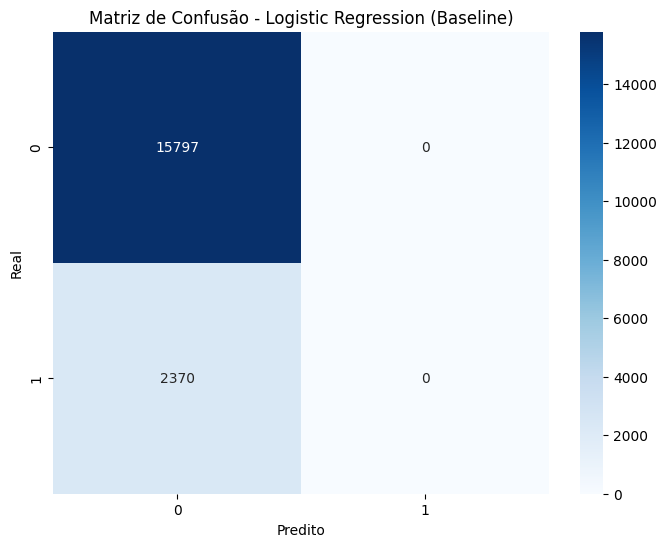

In [19]:
from sklearn.metrics import confusion_matrix

# Matriz de Confusão para visualizar o desempenho do baseline
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Gerando previsões para o treino para poder comparar
y_pred_treino = RegLog.predict(X_treino)

print('Nos dados de TREINO:')
print('---' * 20)
print('Modelo:    Regressão Logística (baseline)\n')
print(f"accuracy:  {accuracy_score(y_treino, y_pred_treino)}")
print(f"precision: {precision_score(y_treino, y_pred_treino, zero_division=0)}")
print(f"recall:    {recall_score(y_treino, y_pred_treino)}")
print(f"f1:        {f1_score(y_treino, y_pred_treino)}")
print()
print('---' * 20)
print('---' * 20)
print()
print('Nos dados de VALIDAÇÃO:')
print('---' * 20)
print('Modelo:    Regressão Logística (baseline)\n')
print(f"accuracy:  {accuracy_score(y_val, y_pred_val)}")
print(f"precision: {precision_score(y_val, y_pred_val, zero_division=0)}")
print(f"recall:    {recall_score(y_val, y_pred_val)}")
print(f"f1:        {f1_score(y_val, y_pred_val)}")
print('---' * 20)


Nos dados de TREINO:
------------------------------------------------------------
Modelo:    Regressão Logística (baseline)

accuracy:  0.8695370981946279
precision: 0.0
recall:    0.0
f1:        0.0

------------------------------------------------------------
------------------------------------------------------------

Nos dados de VALIDAÇÃO:
------------------------------------------------------------
Modelo:    Regressão Logística (baseline)

accuracy:  0.8695436780976495
precision: 0.0
recall:    0.0
f1:        0.0
------------------------------------------------------------


## **Reamostragem dos dados**

In [21]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Aplicando SMOTE (Oversampling Sintético)
smt = SMOTE(random_state=42)
X_smt, y_smt = smt.fit_resample(X_treino, y_treino)

# 2. Aplicando Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_treino, y_treino)

# 3. Aplicando Random Over Sampling (Duplicação)
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_treino, y_treino)

# Treinando com dados SMOTE
model_smt = LogisticRegression(max_iter=1000)
model_smt.fit(X_smt, y_smt)
y_pred_smt = model_smt.predict(X_val)

# Treinando com dados RUS
model_rus = LogisticRegression(max_iter=1000)
model_rus.fit(X_rus, y_rus)
y_pred_rus = model_rus.predict(X_val)

# Treinando com dados ROS
model_ros = LogisticRegression(max_iter=1000)
model_ros.fit(X_ros, y_ros)
y_pred_ros = model_ros.predict(X_val)

print('--- RESULTADOS SMOTE ---')
print(classification_report(y_val, y_pred_smt))

print('\n--- RESULTADOS RANDOM UNDER SAMPLING ---')
print(classification_report(y_val, y_pred_rus))

print('\n--- RESULTADOS RANDOM OVER SAMPLING ---')
print(classification_report(y_val, y_pred_ros))

--- RESULTADOS SMOTE ---
              precision    recall  f1-score   support

         0.0       0.91      0.52      0.66     15797
         1.0       0.17      0.67      0.27      2370

    accuracy                           0.54     18167
   macro avg       0.54      0.59      0.47     18167
weighted avg       0.82      0.54      0.61     18167


--- RESULTADOS RANDOM UNDER SAMPLING ---
              precision    recall  f1-score   support

         0.0       0.92      0.49      0.64     15797
         1.0       0.17      0.70      0.28      2370

    accuracy                           0.52     18167
   macro avg       0.54      0.60      0.46     18167
weighted avg       0.82      0.52      0.59     18167


--- RESULTADOS RANDOM OVER SAMPLING ---
              precision    recall  f1-score   support

         0.0       0.92      0.50      0.65     15797
         1.0       0.17      0.69      0.28      2370

    accuracy                           0.53     18167
   macro avg       0

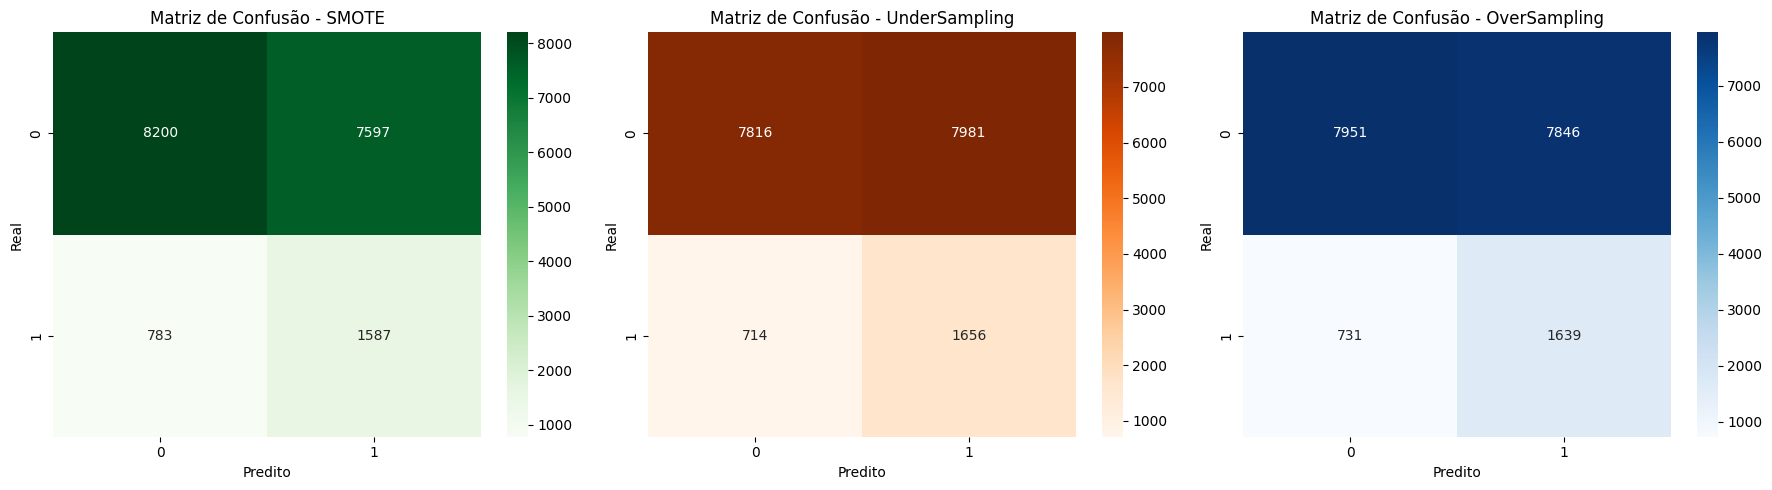

In [22]:
# Configurando a figura para três subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap - SMOTE
sns.heatmap(confusion_matrix(y_val, y_pred_smt), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Matriz de Confusão - SMOTE')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Heatmap - UnderSampling (RUS)
sns.heatmap(confusion_matrix(y_val, y_pred_rus), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Matriz de Confusão - UnderSampling')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

# Heatmap - OverSampling (ROS)
sns.heatmap(confusion_matrix(y_val, y_pred_ros), annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Matriz de Confusão - OverSampling')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

#### **Testando um modelo mais robusto: Random Forest**
Como a Regressão Logística é limitada a relações lineares, vamos testar o Random Forest, que utiliza múltiplas árvores de decisão para melhorar a precisão e reduzir o erro.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Treinando Random Forest com SMOTE
rf_smt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smt.fit(X_smt, y_smt)
y_pred_rf_smt = rf_smt.predict(X_val)

# Treinando Random Forest com Under Sampling (RUS)
rf_rus = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_rus.fit(X_rus, y_rus)
y_pred_rf_rus = rf_rus.predict(X_val)

# Treinando Random Forest com Over Sampling (ROS)
rf_ros = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ros.fit(X_ros, y_ros)
y_pred_rf_ros = rf_ros.predict(X_val)

print('--- RESULTADOS RANDOM FOREST (SMOTE) ---')
print(classification_report(y_val, y_pred_rf_smt))

print('\n--- RESULTADOS RANDOM FOREST (UNDER SAMPLING) ---')
print(classification_report(y_val, y_pred_rf_rus))

print('\n--- RESULTADOS RANDOM FOREST (OVER SAMPLING) ---')
print(classification_report(y_val, y_pred_rf_ros))

--- RESULTADOS RANDOM FOREST (SMOTE) ---
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93     15797
         1.0       0.53      0.55      0.54      2370

    accuracy                           0.88     18167
   macro avg       0.73      0.74      0.73     18167
weighted avg       0.88      0.88      0.88     18167


--- RESULTADOS RANDOM FOREST (UNDER SAMPLING) ---
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     15797
         1.0       0.29      0.74      0.41      2370

    accuracy                           0.73     18167
   macro avg       0.62      0.73      0.62     18167
weighted avg       0.86      0.73      0.77     18167


--- RESULTADOS RANDOM FOREST (OVER SAMPLING) ---
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     15797
         1.0       0.84      0.44      0.58      2370

    accuracy                           0

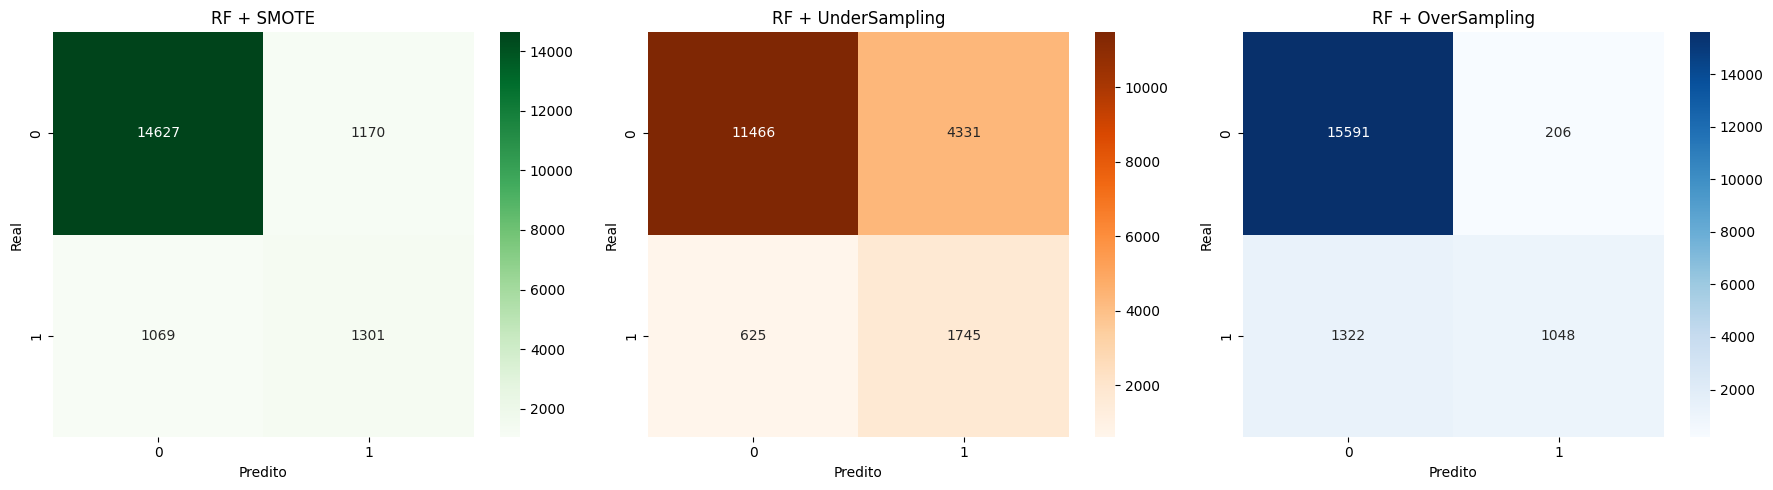

In [24]:
# Configurando a figura para três subplots das matrizes do Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap - RF + SMOTE
sns.heatmap(confusion_matrix(y_val, y_pred_rf_smt), annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('RF + SMOTE')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Heatmap - RF + UnderSampling (RUS)
sns.heatmap(confusion_matrix(y_val, y_pred_rf_rus), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('RF + UnderSampling')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

# Heatmap - RF + OverSampling (ROS)
sns.heatmap(confusion_matrix(y_val, y_pred_rf_ros), annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('RF + OverSampling')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

### **Ajuste de hiperparâmetros com RandomizedSearchCV**

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Definindo o espaço de busca de hiperparâmetros
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Instanciando o modelo base
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Configurando o RandomizedSearchCV
# Usaremos scoring='f1' para equilibrar precisão e recall
rf_rs = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print('Iniciando a otimização do Random Forest com ROS...')
# Treinando com os dados reamostrados via ROS
rf_rs.fit(X_ros, y_ros)

print('Melhores parâmetros encontrados:', rf_rs.best_params_)

# Avaliando o melhor modelo nos dados de validação
best_rf_ros = rf_rs.best_estimator_
y_pred_rf_ros_opt = best_rf_ros.predict(X_val)

print('\n--- RELATÓRIO DE CLASSIFICAÇÃO (RF OTIMIZADO + ROS) ---')
print(classification_report(y_val, y_pred_rf_ros_opt))

Iniciando a otimização do Random Forest com ROS...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores parâmetros encontrados: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}

--- RELATÓRIO DE CLASSIFICAÇÃO (RF OTIMIZADO + ROS) ---
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     15797
         1.0       0.85      0.44      0.58      2370

    accuracy                           0.92     18167
   macro avg       0.89      0.71      0.77     18167
weighted avg       0.91      0.92      0.90     18167



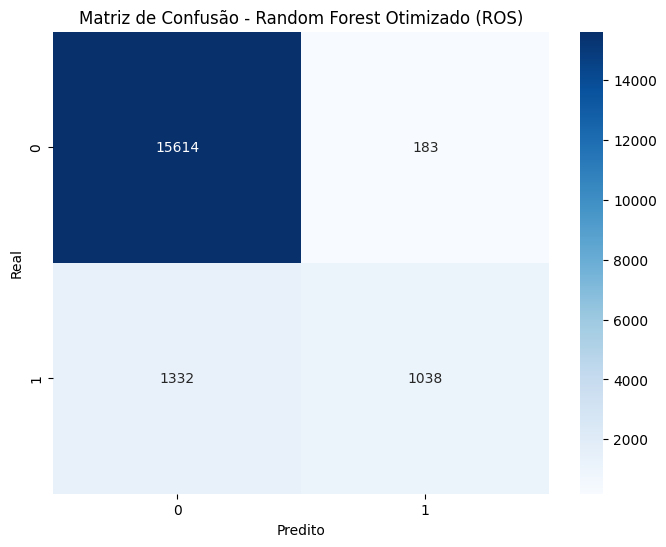

In [28]:
# Visualizando a matriz de confusão do modelo otimizado
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_val, y_pred_rf_ros_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest Otimizado (ROS)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [27]:
from sklearn.metrics import classification_report
import pandas as pd

# Function to extract metrics for the positive class (1.0) and overall accuracy
def extract_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Modelo': model_name,
        'Accuracy': report['accuracy'],
        'Precision_Populares': report['1.0']['precision'],
        'Recall_Populares': report['1.0']['recall'],
        'F1-score_Populares': report['1.0']['f1-score']
    }

# Collect metrics for each model
metrics_data = []

# Baseline Logistic Regression
metrics_data.append(extract_metrics(y_val, y_pred_val, 'Logistic Regression (Baseline)'))

# Logistic Regression with Re-sampling techniques
metrics_data.append(extract_metrics(y_val, y_pred_smt, 'Logistic Regression (SMOTE)'))
metrics_data.append(extract_metrics(y_val, y_pred_rus, 'Logistic Regression (RUS)'))
metrics_data.append(extract_metrics(y_val, y_pred_ros, 'Logistic Regression (ROS)'))

# Random Forest with Re-sampling techniques
metrics_data.append(extract_metrics(y_val, y_pred_rf_smt, 'Random Forest (SMOTE)'))
metrics_data.append(extract_metrics(y_val, y_pred_rf_rus, 'Random Forest (RUS)'))
metrics_data.append(extract_metrics(y_val, y_pred_rf_ros, 'Random Forest (ROS)'))

# Optimized Random Forest with ROS
metrics_data.append(extract_metrics(y_val, y_pred_rf_ros_opt, 'Random Forest Otimizado (ROS)'))

# Create DataFrame from collected metrics
comparative_report_df = pd.DataFrame(metrics_data)

print('Relatório de Classificação Comparativo:')
display(comparative_report_df.round(4))

Relatório de Classificação Comparativo:


,Modelo,Accuracy,Precision_Populares,Recall_Populares,F1-score_Populares
0,Logistic Regression (Baseline),0.8695,0.0000,0.0000,0.0000
1,Logistic Regression (SMOTE),0.5387,0.1728,0.6696,0.2747
2,Logistic Regression (RUS),0.5214,0.1718,0.6987,0.2758
3,Logistic Regression (ROS),0.5279,0.1728,0.6916,0.2765
4,Random Forest (SMOTE),0.8768,0.5265,0.5489,0.5375
5,Random Forest (RUS),0.7272,0.2872,0.7363,0.4132
6,Random Forest (ROS),0.9159,0.8357,0.4422,0.5784
7,Random Forest Otimizado (ROS),0.9166,0.8501,0.4380,0.5781


Random Forest apresentou métricas melhores em relação ao baseline estabelecido no início e aos outros modelos testados.